# Multi-channel spindle detection & cross-channel event syncing — YASA demo

Extends the single-channel ISFS demo (`demo_infraslow_yasa_recheck.ipynb`) to multiple
EEG channels: detect spindles independently on each channel with YASA, then merge
overlapping per-channel events into cross-channel **common events** — spindles that
several channels agree occurred at (approximately) the same time.

- Detect spindles on every channel in `CHANNELS` (`infraslow.processing.spindle.spindles_detect`
  with a channel list — stacks channels into `(n_channels, n_samples)` and runs YASA's
  detector on each one independently, tagging every event with its `Channel`).
- Summarize per-channel spindle counts and rates (`sp.summary(grp_chan=True)`).
- **Sync channels' events**: sweep-merge overlapping `[Start, End]` windows across all
  channels into clusters, and flag clusters spanning ≥2 channels as *common* (synced)
  events. Cross-checked against YASA's own `multi_only=True` consensus and
  `get_coincidence_matrix()`.
- **Figure 1** — pairwise spindle coincidence matrix across channels.
- **Figure 2** — stacked multi-channel EEG with each channel's own detections plus the
  synced common events highlighted across all channels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from infraslow import BioserenityPSGLoader
from infraslow.processing.spindle import (
    spindles_detect,
    _extract_epoch_stages,
    _stages_to_int,
    DEFAULT_STAGE_MAP,
    DEFAULT_EPOCH_SEC,
    DEFAULT_EEG_CHANNELS,
)

plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'

## Load one subject, multiple EEG channels

In [2]:
SUBJECT = '318679'
CHANNELS = list(DEFAULT_EEG_CHANNELS)   # ('F3', 'F4', 'C3', 'C4', 'O1', 'O2')
SF = 200
MIN_BOUT_SEC = 200   # NREM-2 bout length (s) used to pick the Figure 2 window

loader = BioserenityPSGLoader(
    subject_id=SUBJECT, sf=SF, requested_channels=CHANNELS
).load()
sf = float(loader.sf)
n_samples = len(loader.get_channel(CHANNELS[0]))
print(f'{SUBJECT}: {len(CHANNELS)} channels {CHANNELS} @ {sf:g} Hz = {n_samples / sf / 60:.1f} min')

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f4be726af70> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

318679: 6 channels ['F3', 'F4', 'C3', 'C4', 'O1', 'O2'] @ 200 Hz = 458.5 min


## Detect spindles on every channel (YASA multi-channel)

In [3]:
# `ch_names` as a list stacks the channels into (n_channels, n_samples); YASA runs its
# single-channel detector independently on each one and concatenates the results into
# one long-format table tagged by `Channel`. `multi_only=False` keeps every channel's
# own detections -- the cross-channel consensus is built ourselves below instead of
# relying on YASA's built-in `multi_only=True`.
sp = spindles_detect(loader, ch_names=CHANNELS, include=(2,), multi_only=False)
summary = sp.summary()
print(f'{len(summary)} spindles detected across {summary["Channel"].nunique()} channel(s)')
summary.groupby('Channel').size().rename('n_spindles').to_frame()

30-Jul-26 12:42:54 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


916 spindles detected across 6 channel(s)


,n_spindles
Channel,
C3,308
C4,85
F3,104
F4,28
O1,235
O2,156


## Per-channel spindle counts and rates

In [4]:
sp.summary(grp_chan=True)

,Count,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Channel,,,,,,,,,,
C3,308,0.755325,54.535200,30.714685,11.724001,2.079952,0.354459,13.102390,9.376623,0.491027
C4,85,0.743000,64.364135,32.869271,13.004492,2.110590,0.327391,13.105224,9.070588,0.539257
F3,104,0.756394,50.469662,28.372119,10.971265,1.977300,0.307566,12.744517,9.125000,0.503440
F4,28,0.757321,72.351820,33.597453,13.793614,2.059158,0.269049,12.851125,8.500000,0.487949
O1,235,0.752191,50.735467,26.931737,10.434067,1.980690,0.354981,13.238904,9.655319,0.508543
O2,156,0.729744,47.108367,24.914311,9.883269,1.947099,0.356642,13.251124,9.294872,0.484700


## Sync channels' events into common (cross-channel) spindle events

Two spindles on different channels are treated as the *same* underlying event if their
`[Start, End]` windows overlap in time. `sync_channel_events` sweeps every channel's
events together (sorted by `Start`) and transitively merges any that overlap into one
cluster, regardless of which channel they came from. A cluster spanning ≥2 distinct
channels is a **common** (synced) spindle event; a cluster with only one channel is a
channel-private detection. This is cross-checked against two YASA-native measures:
`multi_only=True` (re-detect, keeping only spindles independently found on ≥2 channels)
and `get_coincidence_matrix()` (pairwise fraction of overlapping spindles per channel
pair, used in Figure 1).

In [5]:
def sync_channel_events(summary: pd.DataFrame) -> pd.DataFrame:
    """Merge per-channel spindle [Start, End] windows into common events.

    Sweeps all channels' events together, sorted by Start, and transitively merges any
    that temporally overlap -- regardless of channel -- into one cluster. A cluster
    spanning >=2 distinct channels is a *synced* (cross-channel) spindle event.
    """
    df = summary.sort_values('Start').reset_index(drop=True)
    clusters, current, cur_end = [], [], -np.inf
    for _, row in df.iterrows():
        if current and row['Start'] <= cur_end:
            current.append(row)
            cur_end = max(cur_end, row['End'])
        else:
            if current:
                clusters.append(current)
            current, cur_end = [row], row['End']
    if current:
        clusters.append(current)

    records = [
        dict(
            Start=min(r['Start'] for r in c),
            Peak=np.mean([r['Peak'] for r in c]),
            End=max(r['End'] for r in c),
            n_channels=len(set(r['Channel'] for r in c)),
            n_events=len(c),
            Channels=','.join(sorted(set(r['Channel'] for r in c))),
        )
        for c in clusters
    ]
    return pd.DataFrame.from_records(records)

events = sync_channel_events(summary)
common = events[events['n_channels'] >= 2].reset_index(drop=True)
print(f'{len(events)} merged event(s); {len(common)}/{len(events)} common to >=2 channels')

# Cross-check against YASA's own multi-channel consensus.
sp_multi = spindles_detect(loader, ch_names=CHANNELS, include=(2,), multi_only=True)
n_multi = 0 if sp_multi is None else len(sp_multi.summary())
print(f'YASA multi_only=True keeps {n_multi} spindle(s) (vs {len(common)} synced events above)')

coinc = sp.get_coincidence_matrix()
common['n_channels'].value_counts().sort_index().rename('n_common_events').to_frame()

30-Jul-26 12:43:11 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


561 merged event(s); 228/561 common to >=2 channels
YASA multi_only=True keeps 577 spindle(s) (vs 228 synced events above)


,n_common_events
n_channels,
2,137
3,62
4,23
5,6


## Figure 1 — pairwise spindle coincidence matrix

Scaled coincidence (`sp.get_coincidence_matrix()`): the fraction of each channel pair's
spindles that overlap in time, from 0 (never co-occur) to 1 (every spindle co-occurs).

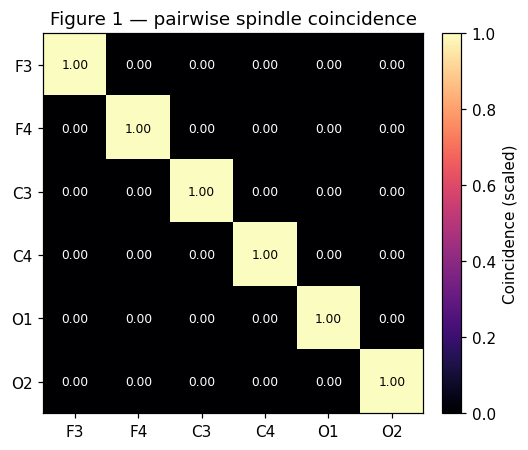

In [6]:
fig, ax = plt.subplots(figsize=(5, 4.2))
mat = coinc.to_numpy()
im = ax.imshow(mat, cmap='magma', vmin=0, vmax=1)
ax.set_xticks(range(len(coinc.columns)), coinc.columns)
ax.set_yticks(range(len(coinc.index)), coinc.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                color='w' if mat[i, j] < 0.6 else 'k', fontsize=8)
ax.set_title('Figure 1 — pairwise spindle coincidence')
fig.colorbar(im, ax=ax, label='Coincidence (scaled)', fraction=0.046, pad=0.04)
fig.tight_layout()

## Figure 2 — multi-channel EEG with per-channel and synced common events

Each channel's raw EEG (grey) with its own detected spindles overlaid in that channel's
color. Purple shading marks the synced **common** events (≥2 channels agree); light grey
shading marks channel-private events. The window is centred on the busiest common event
(most channels agreeing) inside an NREM-2 bout ≥ `MIN_BOUT_SEC` s.

24 NREM-2 bout(s) >= 200s
Zoom window: 3781.8-3811.8 s, centred on a 5-channel common event


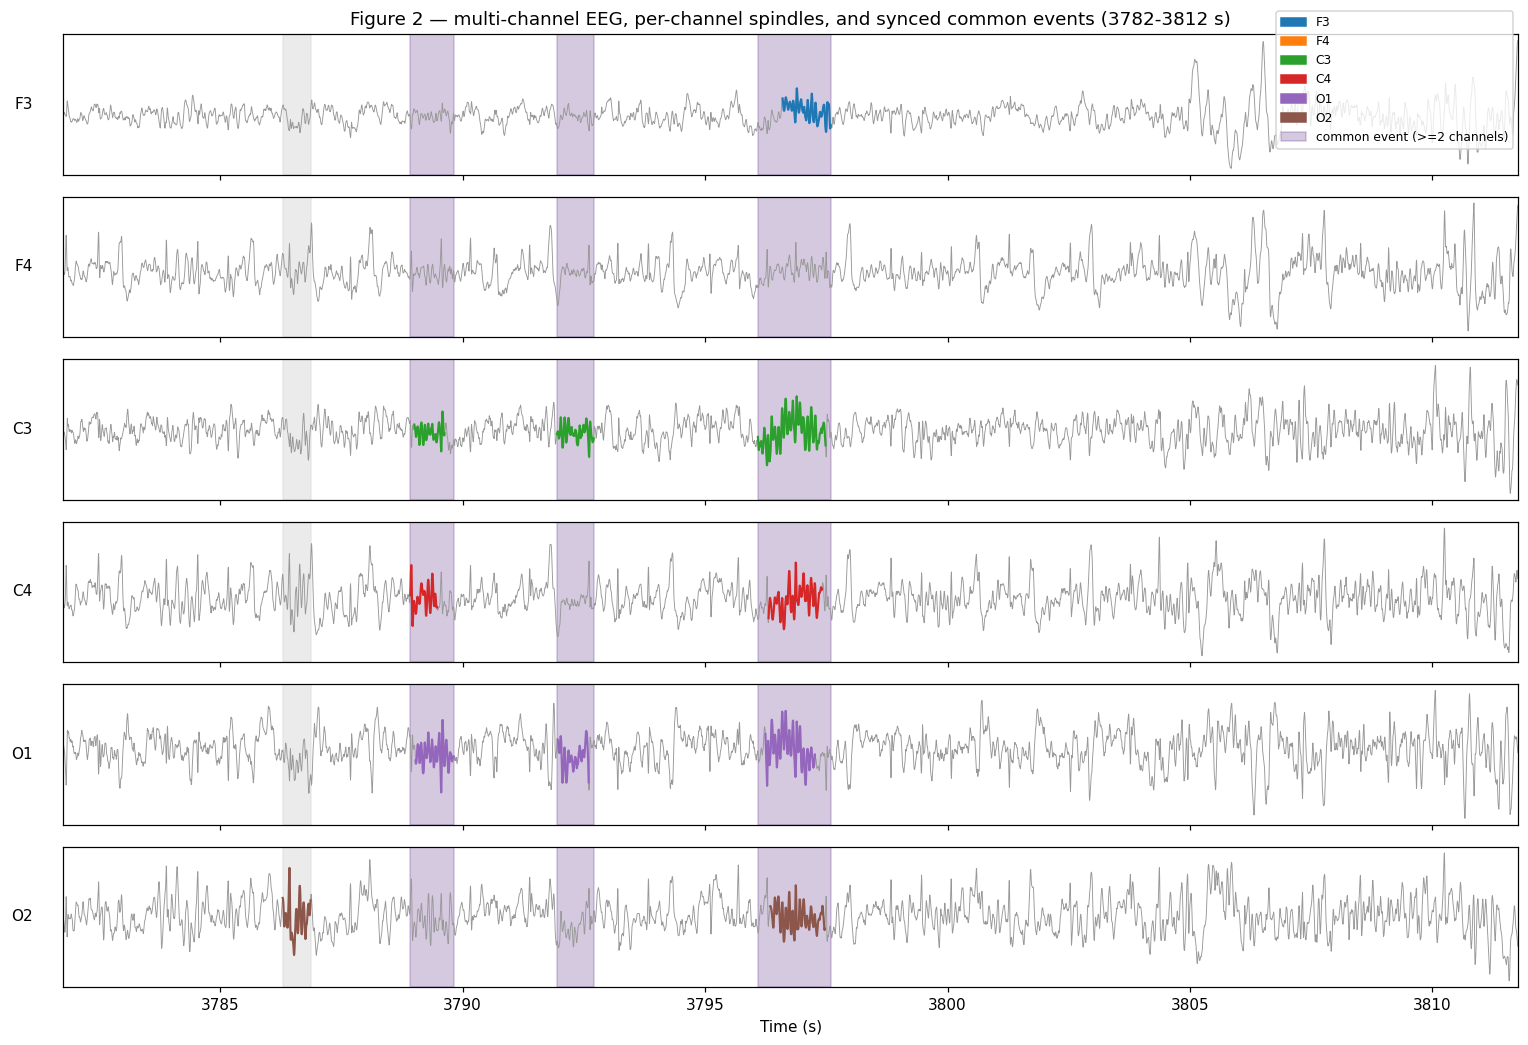

In [7]:
def nrem2_bouts(loader, *, epoch_sec=DEFAULT_EPOCH_SEC, min_dur=MIN_BOUT_SEC, stage_code=2):
    """(start, stop) times (s) of runs of consecutive N2 epochs lasting >= min_dur."""
    codes = _stages_to_int(
        _extract_epoch_stages(loader.annotations, stage_column='stage'),
        DEFAULT_STAGE_MAP,
    )
    bouts, i, n = [], 0, len(codes)
    while i < n:
        if codes[i] == stage_code:
            j = i
            while j < n and codes[j] == stage_code:
                j += 1
            if (j - i) * epoch_sec >= min_dur:
                bouts.append((i * epoch_sec, j * epoch_sec))
            i = j
        else:
            i += 1
    return bouts

bouts = nrem2_bouts(loader)
print(f'{len(bouts)} NREM-2 bout(s) >= {MIN_BOUT_SEC:g}s')

# Centre the view on the busiest common event (most channels agreeing) inside an N2 bout.
in_bout = common[np.any(
    [(common['Peak'] >= a) & (common['Peak'] < b) for a, b in bouts], axis=0
)]
best = in_bout.sort_values(['n_channels', 'n_events'], ascending=False).iloc[0]
WIN_SEC = 30
w0 = max(0.0, best['Peak'] - WIN_SEC / 2)
w1 = w0 + WIN_SEC
WIN = (w0, w1)
print(f'Zoom window: {w0:.1f}-{w1:.1f} s, centred on a {best["n_channels"]}-channel common event')

t = np.arange(n_samples) / sf
chan_colors = dict(zip(CHANNELS, plt.get_cmap('tab10').colors))

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(14, 1.6 * len(CHANNELS)), sharex=True)
for ax, ch in zip(axes, CHANNELS):
    x = np.asarray(loader.get_channel(ch), dtype=float)
    m = (t >= w0) & (t <= w1)
    ax.plot(t[m], x[m], color='0.6', lw=0.6)
    ch_sp = summary[(summary['Channel'] == ch) & (summary['Start'] < w1) & (summary['End'] > w0)]
    for _, r in ch_sp.iterrows():
        seg = (t >= r['Start']) & (t <= r['End'])
        ax.plot(t[seg], x[seg], color=chan_colors[ch], lw=1.4)
    ax.set_ylabel(ch, rotation=0, labelpad=20, ha='right', va='center')
    ax.set_yticks([])

win_events = events[(events['Start'] < w1) & (events['End'] > w0)]
for _, r in win_events.iterrows():
    color = PURPLE if r['n_channels'] >= 2 else '0.85'
    alpha = 0.25 if r['n_channels'] >= 2 else 0.5
    for ax in axes:
        ax.axvspan(r['Start'], r['End'], color=color, alpha=alpha, zorder=0)

axes[-1].set(xlim=WIN, xlabel='Time (s)')
axes[0].set_title(f'Figure 2 — multi-channel EEG, per-channel spindles, and synced '
                   f'common events ({w0:.0f}-{w1:.0f} s)')
handles = [Patch(color=chan_colors[c], label=c) for c in CHANNELS] + [
    Patch(color=PURPLE, alpha=0.25, label='common event (>=2 channels)')]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.99, 0.99),
           frameon=True, fontsize=8)
fig.tight_layout()